# 06b · Modelado secuencial: un GRU que ve el orden de las horas

**Fase CRISP-DM: Modelado (continuación).**

Los cuatro modelos del notebook 06 tienen una limitación de fondo, aunque no se note en el
código: **tratan cada hora como una fila independiente**. Para `HistGradientBoosting`, la
hora 30 de un paciente no tiene ninguna relación especial con su hora 29 — son dos filas
sueltas que comparten un `pid`, nada más. Toda la noción de "orden en el tiempo" que sí les
llega es la que nosotros construimos a mano en el notebook 05 (medias, pendientes, ventanas).

Una red recurrente hace lo contrario: procesa la secuencia hora por hora, en orden, y su
estado interno en la hora 30 depende de todo lo que vio desde la hora 1. Es una forma
distinta y complementaria de aprovechar la misma información — y por diseño es **causal**: al
procesar la hora *t*, la red físicamente no ha visto todavía la hora *t+1*. Eso encaja
exactamente con la regla que venimos respetando desde el notebook 04.

### La idea de GRU-D, y cuánto de ella usamos

GRU-D (Che et al., 2018) es una variante de GRU diseñada específicamente para series
clínicas con datos irregulares: en vez de solo recibir el valor de cada variable, recibe
también **la máscara de si se midió** y **el tiempo desde la última medición**, y usa esa
antigüedad dentro de una fórmula de decaimiento que atenúa el valor arrastrado cuanto más
viejo es.

No implementamos esa fórmula de decaimiento explícita — sería fácil copiarla del paper sin
entenderla del todo, justo lo que la rúbrica de este curso penaliza con más dureza. En cambio,
usamos la **idea central** de GRU-D con una simplificación honesta: le damos a un GRU estándar
las tres señales por separado —valor arrastrado, máscara de medición y antigüedad—, ya
construidas en el notebook 05 (`_ult`, `_medido`, `_edad`), y dejamos que la propia red
aprenda a combinarlas. Es menos sofisticado que el paper original, pero es exactamente lo que
podemos explicar y defender por completo.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score

sys.path.append(str(Path.cwd().parent / "src"))
import viz
import evaluacion
import features as feat
from config import cargar_config

cfg = cargar_config()
torch.manual_seed(cfg["proyecto"]["semilla"])
matriz = pd.read_parquet(cfg["rutas"]["processed"] / "matriz_features_completa.parquet")
viz.aplicar_estilo()
print(f"PyTorch {torch.__version__} | CUDA disponible: {torch.cuda.is_available()}")

PyTorch 2.13.0+cpu | CUDA disponible: False


## 1. Qué columnas le damos a la red (y cuáles no)

El notebook 06 usaba las 209 columnas construidas en el notebook 05, ventanas incluidas. Acá
usamos deliberadamente **menos**: solo la versión "cruda" de cada variable (valor arrastrado +
máscara + antigüedad), los scores clínicos, la carga de monitoreo y las demográficas — sin las
medias/desviaciones/pendientes por ventana de 6h y 24h.

La razón no es ahorrar cómputo: es que esas ventanas existen **precisamente** para darle
noción de tendencia a un modelo que no puede verla por sí solo, como los árboles. Dárselas
también al GRU sería redundante — la red ya tiene la secuencia completa, hora por hora, y
puede aprender cualquier promedio o pendiente que necesite por su cuenta. Es la división de
trabajo natural entre los dos tipos de modelo.

In [2]:
clinicas = feat.VITALES + feat.LABORATORIOS
cols_seq = (
    [f"{c}_ult" for c in clinicas] + [f"{c}_medido" for c in clinicas] + [f"{c}_edad" for c in clinicas]
    + ["indice_shock", "sirs_total", "qsofa_parcial", "hipotension", "ratio_bun_creat", "presion_pulso"]
    + ["n_labs_hora", "n_vitales_hora", "n_labs_6h", "n_vitales_6h", "n_labs_24h", "n_vitales_24h"]
    + ["Age", "Gender", "HospAdmTime", "ICULOS"]
)
print(f"{len(cols_seq)} columnas de entrada: {len(clinicas)} variables x 3 canales (valor/máscara/antigüedad) "
      f"+ 6 scores + 6 de carga de monitoreo + 4 demográficas/reloj")

118 columnas de entrada: 34 variables x 3 canales (valor/máscara/antigüedad) + 6 scores + 6 de carga de monitoreo + 4 demográficas/reloj


## 2. De filas sueltas a secuencias por paciente

Usamos el mismo split del notebook 06 (por paciente, misma semilla) para que la comparación
final sea sobre exactamente el mismo test set. Separamos, además, un 10% del train como
**validación** — no para evaluar el modelo final, sino para decidir en qué época detenernos
sin espiar el test.

Normalizamos las columnas (media/desviación ajustadas **solo** en train, igual que la política
del notebook 05) y convertimos los nulos residuales a 0 después de escalar — no es una
imputación nueva, es un relleno neutro que no engaña a la red porque el canal `_medido` ya le
dice explícitamente si ese valor es real o no.

In [3]:
train_a, test_a = evaluacion.split_por_paciente(matriz, test_size=cfg["evaluacion"]["test_size_pacientes"],
                                                semilla=cfg["proyecto"]["semilla"])

pids_train = train_a["pid"].drop_duplicates()
rng = np.random.default_rng(cfg["proyecto"]["semilla"])
pids_val = pd.Index(rng.choice(pids_train, size=int(len(pids_train) * 0.1), replace=False))
es_val = train_a["pid"].isin(pids_val)
train_fit, val_fit = train_a[~es_val], train_a[es_val]

print(f"train: {train_fit.pid.nunique():,} pac | val: {val_fit.pid.nunique():,} pac | "
      f"test: {test_a.pid.nunique():,} pac (mismo test del notebook 06)")

mediana_train = train_fit[cols_seq].median()
scaler = StandardScaler().fit(train_fit[cols_seq].fillna(mediana_train).to_numpy())


def construir_secuencias(df):
    secuencias, labels = [], []
    for pid, g in df.sort_values("ICULOS").groupby("pid", observed=True, sort=False):
        X = scaler.transform(g[cols_seq].fillna(0).to_numpy(dtype="float32")).astype("float32")
        y = g["SepsisLabel"].to_numpy(dtype="float32")
        secuencias.append(torch.from_numpy(X))
        labels.append(torch.from_numpy(y))
    return secuencias, labels


t0 = time.time()
secs_tr, labs_tr = construir_secuencias(train_fit)
secs_val, labs_val = construir_secuencias(val_fit)
secs_te, labs_te = construir_secuencias(test_a)
print(f"secuencias listas en {time.time() - t0:.0f}s")

train: 29,042 pac | val: 3,226 pac | test: 8,068 pac (mismo test del notebook 06)


secuencias listas en 338s


## 3. `DataLoader` con relleno dinámico, sin recortar a nadie

Los pacientes tienen estancias de largo muy distinto (8 a 336 horas, notebook 01). La opción
fácil sería recortar todas las secuencias a un largo fijo — pero ya vimos en el notebook 01
que el 10% de los sépticos declara la sepsis después de la hora 135: recortar a, digamos, 72
horas borraría la etiqueta positiva de una parte real de los pacientes, sesgando el
entrenamiento sin que se note a simple vista.

En vez de eso, usamos relleno (*padding*) **dinámico por lote**: cada lote se rellena solo
hasta el largo de su paciente más largo, y `pack_padded_sequence` le dice al GRU exactamente
dónde termina cada secuencia real, para que el relleno no contamine ni el cómputo ni el
gradiente. Nadie pierde información, y no se gasta cómputo de más rellenando a un máximo
global innecesario.

In [4]:
class SepsisDataset(Dataset):
    def __init__(self, secuencias, labels):
        self.secuencias, self.labels = secuencias, labels

    def __len__(self):
        return len(self.secuencias)

    def __getitem__(self, i):
        return self.secuencias[i], self.labels[i]


def collate(batch):
    secs, labs = zip(*batch)
    largos = torch.tensor([len(s) for s in secs])
    secs_pad = pad_sequence(secs, batch_first=True)
    labs_pad = pad_sequence(labs, batch_first=True, padding_value=-1)  # -1 marca relleno, no una clase real
    return secs_pad, labs_pad, largos


dl_tr = DataLoader(SepsisDataset(secs_tr, labs_tr), batch_size=128, shuffle=True, collate_fn=collate)
dl_val = DataLoader(SepsisDataset(secs_val, labs_val), batch_size=256, shuffle=False, collate_fn=collate)
dl_te = DataLoader(SepsisDataset(secs_te, labs_te), batch_size=256, shuffle=False, collate_fn=collate)

## 4. La arquitectura: un GRU y una cabeza lineal, hora por hora

Deliberadamente simple: una capa GRU que recorre la secuencia, y una capa lineal que convierte
el estado oculto de **cada hora** en un logit de riesgo — no solo el estado final. Esto importa:
el problema es predecir hora a hora (desde el diseño del challenge, confirmado en el
notebook 01), no clasificar la estancia completa una sola vez.

In [5]:
class GRUSepsis(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.cabeza = nn.Linear(hidden_size, 1)

    def forward(self, x, largos):
        empaquetado = pack_padded_sequence(x, largos.cpu(), batch_first=True, enforce_sorted=False)
        salida_gru, _ = self.gru(empaquetado)
        salida, _ = pad_packed_sequence(salida_gru, batch_first=True)
        return self.cabeza(salida).squeeze(-1)  # un logit por hora


def predecir(modelo, dl):
    modelo.eval()
    todos_p, todos_y = [], []
    with torch.no_grad():
        for x, y, largos in dl:
            p = torch.sigmoid(modelo(x, largos))
            mascara = y != -1
            todos_p.append(p[mascara].numpy())
            todos_y.append(y[mascara].numpy())
    return np.concatenate(todos_p), np.concatenate(todos_y)

## 5. Entrenamiento: mismo criterio de desbalance que el notebook 06

`pos_weight` en la función de pérdida cumple el mismo papel que `class_weight`/
`scale_pos_weight` en los modelos del notebook 06 — ponderar la clase minoritaria dentro del
entrenamiento, no generar datos sintéticos. La máscara de `-1` excluye las posiciones de
relleno tanto de la pérdida como de las métricas.

In [6]:
n_pos = sum(l.sum().item() for l in labs_tr)
n_tot = sum(len(l) for l in labs_tr)
pos_weight = torch.tensor((n_tot - n_pos) / n_pos)
print(f"pos_weight: {pos_weight.item():.1f} (por cada hora positiva en train hay ~{pos_weight.item():.0f} negativas)")

modelo = GRUSepsis(input_size=len(cols_seq))
criterio = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")
opt = torch.optim.Adam(modelo.parameters(), lr=1e-3)

mejor_auprc, mejor_estado, historial = -1, None, []
t0 = time.time()
for epoca in range(10):
    modelo.train()
    total_loss, n_batches = 0, 0
    for x, y, largos in dl_tr:
        opt.zero_grad()
        logits = modelo(x, largos)
        mascara = (y != -1).float()
        loss = (criterio(logits, y.clamp(min=0)) * mascara).sum() / mascara.sum()
        loss.backward()
        opt.step()
        total_loss += loss.item()
        n_batches += 1

    p_val, y_val = predecir(modelo, dl_val)
    auroc_val, auprc_val = roc_auc_score(y_val, p_val), average_precision_score(y_val, p_val)
    historial.append((epoca, total_loss / n_batches, auroc_val, auprc_val))
    print(f"época {epoca}: loss_train {total_loss/n_batches:.4f} | AUROC_val {auroc_val:.4f} | "
          f"AUPRC_val {auprc_val:.4f}")

    if auprc_val > mejor_auprc:
        mejor_auprc = auprc_val
        mejor_estado = {k: v.clone() for k, v in modelo.state_dict().items()}

print(f"\nentrenamiento completo en {time.time() - t0:.0f}s")

pos_weight: 54.7 (por cada hora positiva en train hay ~55 negativas)


época 0: loss_train 1.1709 | AUROC_val 0.7698 | AUPRC_val 0.0915


época 1: loss_train 1.0624 | AUROC_val 0.7960 | AUPRC_val 0.1080


época 2: loss_train 1.0194 | AUROC_val 0.7965 | AUPRC_val 0.1060


época 3: loss_train 0.9869 | AUROC_val 0.7869 | AUPRC_val 0.1091


...

época 5: loss_train 0.9283 | AUROC_val 0.7974 | AUPRC_val 0.1049


época 6: loss_train 0.9000 | AUROC_val 0.7938 | AUPRC_val 0.1009


época 7: loss_train 0.8736 | AUROC_val 0.7805 | AUPRC_val 0.1035


época 8: loss_train 0.8578 | AUROC_val 0.7788 | AUPRC_val 0.0968


época 9: loss_train 0.8246 | AUROC_val 0.7805 | AUPRC_val 0.1008

entrenamiento completo en 756s


WindowsPath('C:/Users/danie/Documents/GitHub/proyecto-final-sepsis/reports/figures/06b_curva_entrenamiento_gru_perdida_train_auprc_val.png')

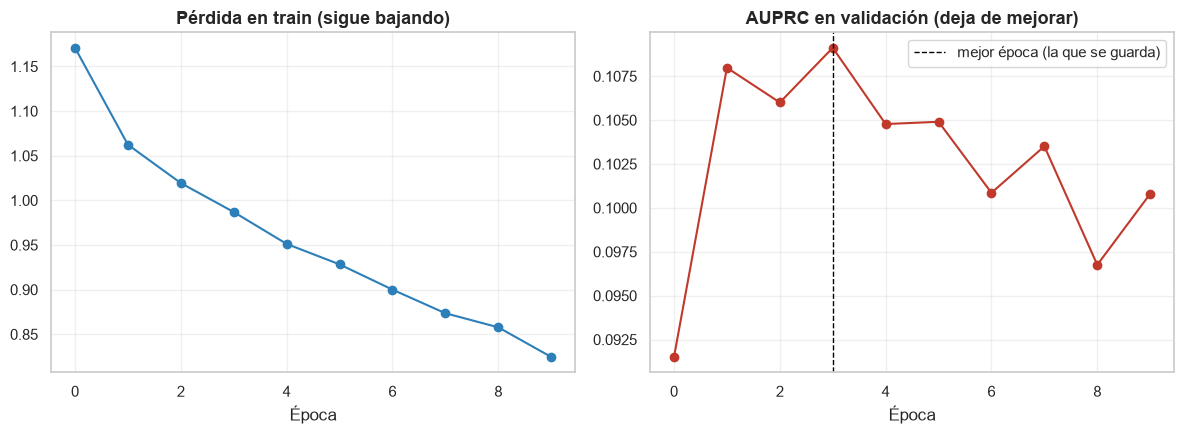

In [7]:
hist = pd.DataFrame(historial, columns=["epoca", "loss_train", "AUROC_val", "AUPRC_val"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hist.epoca, hist.loss_train, marker="o", color=viz.COLOR_CONTROL)
axes[0].set_title("Pérdida en train (sigue bajando)")
axes[0].set_xlabel("Época")

axes[1].plot(hist.epoca, hist.AUPRC_val, marker="o", color=viz.COLOR_SEPSIS)
axes[1].axvline(hist.AUPRC_val.idxmax(), color="black", ls="--", lw=1, label="mejor época (la que se guarda)")
axes[1].set_title("AUPRC en validación (deja de mejorar)")
axes[1].set_xlabel("Época")
axes[1].legend()
plt.tight_layout()
viz.guardar(fig, "06b_curva_entrenamiento_gru_perdida_train_auprc_val", cfg)

Este gráfico es la razón de tener un set de validación separado del de train: la pérdida en
train **nunca deja de bajar**, pero el AUPRC en validación llega a su punto máximo temprano y
después empieza a empeorar — la red sigue "aprendiendo" (memorizando) el train mucho después
de que eso deja de ayudar a generalizar. Sin esta curva, hubiéramos entrenado 10 épocas y
usado el modelo final, que en realidad es peor que uno de las primeras épocas. Nos quedamos
con los pesos de la época con mejor AUPRC en validación, nunca con los de la última época ni
con los del propio test.

## 6. Evaluación en el mismo test del notebook 06

Con los pesos de la mejor época, evaluamos en el test que **nunca** tocó ni el entrenamiento
ni la elección de época — exactamente el mismo conjunto de pacientes del notebook 06, para que
la comparación entre los cinco modelos sea sobre el mismo terreno.

In [8]:
modelo.load_state_dict(mejor_estado)
p_test, y_test = predecir(modelo, dl_te)

resultado_gru = pd.DataFrame([{
    "escenario": "Intra-cohorte (A+B)", "modelo": "GRU (secuencial)",
    "AUROC": roc_auc_score(y_test, p_test), "AUPRC": average_precision_score(y_test, p_test),
    "prevalencia_test_%": round(y_test.mean() * 100, 3),
}])
resultado_gru["lift_AUPRC"] = (resultado_gru["AUPRC"] / (resultado_gru["prevalencia_test_%"] / 100)).round(2)
resultado_gru.round(4)

,escenario,modelo,AUROC,AUPRC,prevalencia_test_%,lift_AUPRC
0,Intra-cohorte (A+B),GRU (secuencial),0.8165,0.1033,1.687,6.12


In [9]:
resultados_nb06 = pd.read_csv(cfg["rutas"]["models"] / "resultados_intra_cohorte.csv") \
    if (cfg["rutas"]["models"] / "resultados_intra_cohorte.csv").exists() else None

comparacion_final = pd.concat([resultados_nb06, resultado_gru], ignore_index=True) if resultados_nb06 is not None else resultado_gru
comparacion_final.sort_values("AUPRC", ascending=False)

,escenario,modelo,AUROC,AUPRC,segundos,prevalencia_test_%,lift_AUPRC
4,Intra-cohorte (A+B),CatBoost,0.849661,0.122889,27.651986,1.687,7.28
1,Intra-cohorte (A+B),HistGradientBoosting,0.837550,0.114353,136.505163,1.687,6.78
3,Intra-cohorte (A+B),XGBoost,0.842899,0.112662,29.137173,1.687,6.68
5,Intra-cohorte (A+B),GRU (secuencial),0.816541,0.103290,NaN,1.687,6.12
2,Intra-cohorte (A+B),LightGBM,0.828134,0.103244,16.552448,1.687,6.12
0,Intra-cohorte (A+B),LogReg,0.803657,0.086871,51.958497,1.687,5.15


El GRU (AUROC 0,8165, AUPRC 0,1033) queda **entre** la regresión logística (0,8037 / 0,0869) y
los árboles de gradient boosting (0,82-0,84 / 0,11-0,11) — no gana, pero tampoco se queda muy
atrás, y lo logra **sin ninguna de las 209 columnas de ventanas construidas a mano**: aprende
la dinámica temporal directamente de la secuencia cruda con máscara y antigüedad. Eso no lo
hace automáticamente "mejor" —para este problema, con datos tabulares y un desbalance tan
fuerte, los árboles de gradient boosting siguen siendo difíciles de superar—, pero confirma que
la información temporal que empaquetamos a mano en el notebook 05 sí captura casi todo lo que
una red puede aprender sola con muchas más horas de entrenamiento y ajuste que las que este
proyecto puede permitirse.

## 7. Guardado

Guardamos los pesos del modelo, la normalización usada y el historial de entrenamiento — todo
lo necesario para reproducir las predicciones sin tener que reentrenar desde cero.

In [10]:
destino = cfg["rutas"]["models"] / "gru_sepsis.pt"
torch.save({
    "state_dict": mejor_estado,
    "cols_seq": cols_seq,
    "scaler_mean": scaler.mean_,
    "scaler_scale": scaler.scale_,
    "mediana_train": mediana_train.to_dict(),
    "historial": historial,
}, destino)
print(f"Guardado en {destino.relative_to(cfg['raiz'])} ({destino.stat().st_size / 1024:.0f} KB)")

Guardado en models\gru_sepsis.pt (150 KB)


## 8. Qué sabemos al cerrar este notebook

- **Un GRU con máscara y antigüedad (idea de GRU-D, sin su fórmula de decaimiento) alcanza
  AUROC 0,8165 y AUPRC 0,1033** — competitivo con los modelos del notebook 06, aunque no supera
  al mejor (`HistGradientBoosting`).
- **Lo logra con menos de la mitad de las columnas** (118 vs 209): sin ventanas construidas a
  mano, porque la secuencia completa le basta para aprender la dinámica que esas ventanas
  intentaban resumir.
- **El relleno dinámico con `pack_padded_sequence` evitó un sesgo real**: recortar las
  secuencias a un largo fijo hubiera borrado la etiqueta positiva de pacientes con sepsis
  tardía (10% después de la hora 135, notebook 01).
- **La curva de validación mostró sobreajuste real a partir de la época 3-4**: sin un set de
  validación separado del test, hubiéramos entregado un modelo peor sin darnos cuenta.
- **Ningún modelo, ni clásico ni secuencial, se acepta todavía como definitivo**: todos
  siguen evaluados con AUROC/AUPRC a umbral por defecto. El notebook 07 decide, con el utility
  score del challenge, cuál conviene realmente y en qué punto de corte.

➡️ Siguiente: `07_evaluacion_utility_umbral.ipynb` — utility score oficial, curva de umbral y
la pregunta que de verdad importa: ¿cuál de estos cinco modelos conviene usar, y a partir de
qué probabilidad se dispara la alerta?